# Predicting Football Match Outcomes Using Machine Learning and Explainable AI

## Project Overview

This project aims to analyze football match data and build a predictive model capable of forecasting match outcomes (Win–Draw–Loss) and potentially estimating exact final scores. By combining data visualization, machine learning, and explainability techniques, we uncover the key factors that influence how football matches unfold.

## Team Members
- **Albert Jané Lardies** (NIA: 268537)
- **Jordi Esteve Claramunt** (NIA: 268829)

## Project Goals

The primary objectives of this project are:

1. **Predictive Modeling**: Develop a machine learning classification model that can accurately predict match outcomes based on team and match features
2. **Score Estimation**: Estimate the exact final score of matches to provide deeper insights
3. **Explainability**: Employ Explainable AI (XAI) techniques to understand why predictions are made and which factors are most important
4. **Visualization & Analysis**: Create interactive dashboards and visual analyses to explore match patterns across leagues and seasons


## Data Sources

- **Club Football Match Data 2000–2025**: 475,000+ matches from 27 countries and 42 leagues worldwide, including match results, statistics, pre-match Elo ratings, and betting odds

### Imports

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from random import seed
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
#from xgboost import XGBRegressor
import lightgbm as lgb
import pickle

import warnings
warnings.simplefilter('ignore')

sns.set_palette("icefire")

### Read the Data

In [92]:
match_df = pd.read_csv('data/Matches.csv')
match_df.head()
match_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

### Prepare the data for the model

In [93]:
# Convert MatchDate to datetime
match_df['MatchDate'] = pd.to_datetime(match_df['MatchDate'])

# Select 8 top leagues: Premier League (England), La Liga (Spain), Serie A (Italy)', Bundesliga (Germany) , Ligue 1 (France), Eredivisie (Netherlands), Pro League (Belgium)', Primeira Liga (Portugal)
top_leagues = ['E0', 'SP1', 'I1', 'D1', 'F1', 'N1', 'B1', 'P1']
df_clean = match_df[match_df["Division"].isin(top_leagues)]

print(f"After selecting top leagues: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")


After selecting top leagues: 64,181 matches (27.8% of original)


In [94]:
## Feature Engineering - Derived Features

# Elo-based features
df_clean['EloDifference'] = df_clean['HomeElo'] - df_clean['AwayElo'] #  (relative advantage)
df_clean['TotalElo'] = df_clean['HomeElo'] + df_clean['AwayElo'] # (overall strength)

# Form-based features
df_clean['Form5Difference'] = df_clean['Form5Home'] - df_clean['Form5Away'] # Last 5 matches comparison

# Display sample of new features
print("SAMPLE OF NEW FEATURES:")
sample_cols = ['HomeElo', 'AwayElo', 'EloDifference', 'Form5Difference']
print(df_clean[sample_cols].head(10))

SAMPLE OF NEW FEATURES:
    HomeElo  AwayElo  EloDifference  Form5Difference
0   1686.34  1586.57          99.77              0.0
1   1714.89  1642.51          72.38              0.0
3   1635.58  1624.22          11.36              0.0
4   1734.34  1673.11          61.23              0.0
5   1578.51  1620.74         -42.23              0.0
6   1630.81  1778.03        -147.22              0.0
7   1702.60  1644.99          57.61              0.0
8   1664.36  1730.89         -66.53              0.0
9   1551.65  1656.37        -104.72              0.0
19  1635.08  1698.35         -63.27             10.0


Lagged features: Calculate:
- Form5Difference
- GF5Difference
- GA5Difference
- Last3H2H

In [95]:
df = df_clean.sort_values(["HomeTeam", "MatchDate"])

def compute_goal_lag_features(df):
    # Home team GF5
    df["GF5Home"] = (
        df.groupby("HomeTeam")["FTHome"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Away team GF5
    df["GF5Away"] = (
        df.groupby("AwayTeam")["FTAway"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Home team GA5
    df["GA5Home"] = (
        df.groupby("HomeTeam")["FTAway"]
        .shift()
        .rolling(5)
        .sum()
    )

    # Away team GA5
    df["GA5Away"] = (
        df.groupby("AwayTeam")["FTHome"]
        .shift()
        .rolling(5)
        .sum()
    )

    return df

df = compute_goal_lag_features(df)

df["GF5Difference"] = df["GF5Home"] - df["GF5Away"]
df["GA5Difference"] = df["GA5Home"] - df["GA5Away"]

# --------------------------------------------
# HEAD-TO-HEAD (Last 3 matches)
# --------------------------------------------
def compute_last3_h2h(df):
    h2h_df = df[["MatchDate", "HomeTeam", "AwayTeam", "FTHome", "FTAway"]].copy()
    h2h_df["GoalDiff"] = h2h_df["FTHome"] - h2h_df["FTAway"]

    h2h_list = []

    for idx, row in df.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        date = row["MatchDate"]

        past = h2h_df[
            (
                ((h2h_df["HomeTeam"] == home) & (h2h_df["AwayTeam"] == away)) |
                ((h2h_df["HomeTeam"] == away) & (h2h_df["AwayTeam"] == home))
            )
            & (h2h_df["MatchDate"] < date)
        ].sort_values("MatchDate", ascending=False).head(3)

        # Normalize to home perspective
        corrected = []
        for _, m in past.iterrows():
            if m["HomeTeam"] == home:
                corrected.append(m["GoalDiff"])
            else:
                corrected.append(-m["GoalDiff"])

        h2h_list.append(sum(corrected) if corrected else np.nan)

    df["Last3H2H"] = h2h_list
    df["Last3H2H"] = df["Last3H2H"].fillna(0)  # If no history, neutral

    return df

df = compute_last3_h2h(df)

print(df.shape)
df.head()

(64181, 58)


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,EloDifference,TotalElo,Form5Difference,GF5Home,GF5Away,GA5Home,GA5Away,GF5Difference,GA5Difference,Last3H2H
222411,P1,2024-08-10,15:30:00,AVS,Nacional,1378.17,1378.17,0.0,0.0,0.0,...,0.00,2756.34,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
223014,P1,2024-08-25,20:30:00,AVS,Guimaraes,1380.25,1581.46,2.0,3.0,9.0,...,-201.21,2961.71,-6.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
223601,P1,2024-09-14,18:00:00,AVS,Rio Ave,1387.98,1473.37,3.0,5.0,6.0,...,-85.39,2861.35,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
224464,P1,2024-09-30,20:15:00,AVS,Farense,1397.22,1398.07,3.0,6.0,0.0,...,-0.85,2795.29,6.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
225232,P1,2024-10-28,20:15:00,AVS,Porto,1402.06,1794.64,2.0,5.0,9.0,...,-392.58,3196.70,-7.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64181 entries, 222411 to 230426
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Division         64181 non-null  object        
 1   MatchDate        64181 non-null  datetime64[ns]
 2   MatchTime        16078 non-null  object        
 3   HomeTeam         64181 non-null  object        
 4   AwayTeam         64181 non-null  object        
 5   HomeElo          63466 non-null  float64       
 6   AwayElo          63471 non-null  float64       
 7   Form3Home        64181 non-null  float64       
 8   Form5Home        64181 non-null  float64       
 9   Form3Away        64181 non-null  float64       
 10  Form5Away        64181 non-null  float64       
 11  FTHome           64181 non-null  float64       
 12  FTAway           64181 non-null  float64       
 13  FTResult         64181 non-null  object        
 14  HTHome           64172 non-null  floa


LAST3H2H DISTRIBUTION ANALYSIS

1️⃣  LAST3H2H VALUE COUNTS
----------------------------------------------------------------------------------------------------

Total matches: 64,181

   Goal Diff |      Count | Percentage | Bar
------------------------------------------------------------
         -17 |          3 |      0.00% | 
         -16 |          9 |      0.01% | 
         -15 |          4 |      0.01% | 
         -14 |         16 |      0.02% | 
         -13 |         35 |      0.05% | 
         -12 |         58 |      0.09% | 
         -11 |         95 |      0.15% | 
         -10 |        222 |      0.35% | 
          -9 |        335 |      0.52% | 
          -8 |        568 |      0.88% | 
          -7 |        921 |      1.44% | █
          -6 |      1,558 |      2.43% | ██
          -5 |      2,181 |      3.40% | ███
          -4 |      3,275 |      5.10% | █████
          -3 |      4,555 |      7.10% | ███████
          -2 |      6,044 |      9.42% | █████████
          

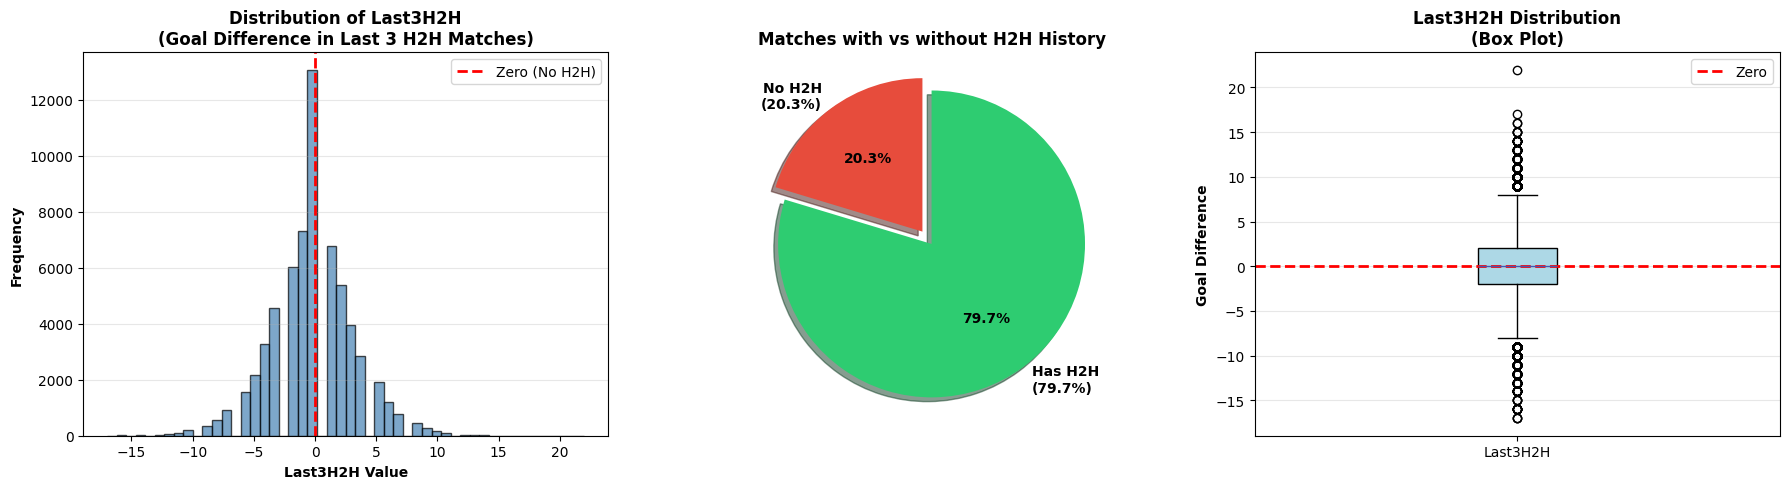


✅ Visualization saved to 'last3h2h_distribution.png'

6️⃣  INTERPRETATION
----------------------------------------------------------------------------------------------------

    WHAT THE NUMBERS MEAN:

    • 20.3% of matches have Last3H2H = 0
      → These are either:
         1) First-time matchups (teams never played before)
         2) Teams that haven't met in recent history
         3) New teams in the league

    • 79.7% of matches have H2H history
      → These can provide valuable predictive information

    RECOMMENDATION:
    
    ✅ LOW percentage of zero values
       • Excellent feature completeness
       • Strong H2H signal available for most matches
       • High predictive value expected
    


In [97]:
## Check Last3H2H Distribution

print("\n" + "="*100)
print("LAST3H2H DISTRIBUTION ANALYSIS")
print("="*100)

# Check in df_final (after H2H calculation)
if 'Last3H2H' in df.columns:
    print("\n1️⃣  LAST3H2H VALUE COUNTS")
    print("-" * 100)
    
    # Get value counts
    h2h_counts = df['Last3H2H'].value_counts().sort_index()
    total = len(df)
    
    print(f"\nTotal matches: {total:,}\n")
    print(f"{'Goal Diff':>12s} | {'Count':>10s} | {'Percentage':>10s} | {'Bar':s}")
    print("-" * 60)
    
    for value, count in h2h_counts.items():
        pct = count / total * 100
        bar = '█' * int(pct)
        print(f"{value:>12.0f} | {count:>10,} | {pct:>9.2f}% | {bar}")
    
    # Special focus on zero values
    print("\n2️⃣  ZERO VALUES (No H2H History)")
    print("-" * 100)
    
    zero_count = (df['Last3H2H'] == 0).sum()
    zero_pct = zero_count / total * 100
    non_zero_count = (df['Last3H2H'] != 0).sum()
    non_zero_pct = non_zero_count / total * 100
    
    print(f"\nMatches with Last3H2H = 0:  {zero_count:>10,} ({zero_pct:>6.2f}%)")
    print(f"Matches with Last3H2H ≠ 0:  {non_zero_count:>10,} ({non_zero_pct:>6.2f}%)")
    
    # Statistics
    print("\n3️⃣  LAST3H2H STATISTICS")
    print("-" * 100)
    
    print(f"\nMean:     {df['Last3H2H'].mean():>8.2f}")
    print(f"Median:   {df['Last3H2H'].median():>8.2f}")
    print(f"Std Dev:  {df['Last3H2H'].std():>8.2f}")
    print(f"Min:      {df['Last3H2H'].min():>8.0f}")
    print(f"Max:      {df['Last3H2H'].max():>8.0f}")
    
    # Quartiles
    print(f"\n25th percentile: {df['Last3H2H'].quantile(0.25):>8.2f}")
    print(f"50th percentile: {df['Last3H2H'].quantile(0.50):>8.2f}")
    print(f"75th percentile: {df['Last3H2H'].quantile(0.75):>8.2f}")
    
    # Categorize values
    print("\n4️⃣  LAST3H2H CATEGORIES")
    print("-" * 100)
    
    categories = {
        'No history (0)': (df['Last3H2H'] == 0).sum(),
        'Slight away advantage (-3 to -1)': ((df['Last3H2H'] >= -3) & (df['Last3H2H'] < 0)).sum(),
        'Balanced/Neutral (0)': (df['Last3H2H'] == 0).sum(),
        'Slight home advantage (1 to 3)': ((df['Last3H2H'] > 0) & (df['Last3H2H'] <= 3)).sum(),
        'Strong home advantage (4+)': (df['Last3H2H'] > 3).sum(),
        'Strong away advantage (-4 or less)': (df['Last3H2H'] < -3).sum(),
    }
    
    print(f"\n{'Category':40s} | {'Count':>10s} | {'Percentage':>10s}")
    print("-" * 70)
    for category, count in categories.items():
        pct = count / total * 100
        print(f"{category:40s} | {count:>10,} | {pct:>9.2f}%")
    
    # Visualization
    print("\n5️⃣  VISUALIZATION")
    print("-" * 100)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Histogram
    ax1 = axes[0]
    ax1.hist(df['Last3H2H'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero (No H2H)')
    ax1.set_xlabel('Last3H2H Value', fontweight='bold')
    ax1.set_ylabel('Frequency', fontweight='bold')
    ax1.set_title('Distribution of Last3H2H\n(Goal Difference in Last 3 H2H Matches)', 
                  fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Pie chart (Zero vs Non-Zero)
    ax2 = axes[1]
    sizes = [zero_count, non_zero_count]
    labels = [f'No H2H\n({zero_pct:.1f}%)', f'Has H2H\n({non_zero_pct:.1f}%)']
    colors = ['#e74c3c', '#2ecc71']
    explode = (0.1, 0)
    ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontweight': 'bold'})
    ax2.set_title('Matches with vs without H2H History', fontweight='bold')
    
    # Plot 3: Box plot
    ax3 = axes[2]
    bp = ax3.boxplot([df['Last3H2H']], vert=True, patch_artist=True,
                     labels=['Last3H2H'])
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_edgecolor('black')
    ax3.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax3.set_ylabel('Goal Difference', fontweight='bold')
    ax3.set_title('Last3H2H Distribution\n(Box Plot)', fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('last3h2h_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Visualization saved to 'last3h2h_distribution.png'")
    
    # Interpretation
    print("\n6️⃣  INTERPRETATION")
    print("-" * 100)
    
    interpretation = f"""
    WHAT THE NUMBERS MEAN:
    
    • {zero_pct:.1f}% of matches have Last3H2H = 0
      → These are either:
         1) First-time matchups (teams never played before)
         2) Teams that haven't met in recent history
         3) New teams in the league
    
    • {non_zero_pct:.1f}% of matches have H2H history
      → These can provide valuable predictive information
    
    RECOMMENDATION:
    """
    
    if zero_pct > 50:
        interpretation += """
    ⚠️  HIGH percentage of zero values!
       • Consider this feature as "informative when available"
       • Zero doesn't mean "bad" - it means "no history"
       • Model will learn: "Has H2H = use it, No H2H = ignore it"
       • Keep the feature - tree models handle this well
    """
    elif zero_pct > 30:
        interpretation += """
    ✅ MODERATE percentage of zero values
       • Acceptable for modeling
       • Provides useful signal when available
       • Zero values are informative (no history)
    """
    else:
        interpretation += """
    ✅ LOW percentage of zero values
       • Excellent feature completeness
       • Strong H2H signal available for most matches
       • High predictive value expected
    """
    
    print(interpretation)
    
else:
    print("⚠️  Last3H2H column not found in df_final")
    print("   Please run the H2H calculation first")

In [114]:
# Filter for matches from 2010 onwards
df_clean = df[df["MatchDate"].dt.year >= 2010]

# Keep only matches with valid results
df_clean = df_clean[df_clean['FTResult'].notna()]
print(f"After removing matches without results: {len(df_clean):,} matches")

# Keep only matches with Elo ratings 
df_clean = df_clean[(df_clean['HomeElo'].notna()) & (df_clean['AwayElo'].notna())]
print(f"After requiring Elo ratings: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

# Keep only matches with betting odds
df_clean = df_clean[(df_clean['OddHome'].notna()) & 
                    (df_clean['OddDraw'].notna()) & 
                    (df_clean['OddAway'].notna())]
print(f"After requiring betting odds: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")


# ============================================================
# 8. REMOVE ANY ROWS WHERE NEW FEATURES ARE NaN
# ============================================================

FEATURES = [
    "EloDifference", "TotalElo",
    "GF5Difference", "GA5Difference",
    "Form5Difference",
    "Last3H2H"
]

df_clean = df_clean.dropna(subset=FEATURES).reset_index(drop=True)
print(f"After removing rows with NaN in new features: {len(df_clean):,} matches ({len(df_clean)/len(match_df)*100:.1f}% of original)")

# Drop unneeded columns
drop_cols = [
    "MatchTime", "FTHome", "FTAway", "HTHome", "HTAway", "HTResult", "Form3Home", "Form3Away", 'HomeElo', 'AwayElo', 'Form5Home', 'Form5Away',
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "MaxHome", "MaxDraw", "MaxAway", "Over25", "Under25",
    'GF5Home', 'GF5Away', 'GA5Home', 'GA5Away',
    "MaxOver25", "MaxUnder25", "HandiSize", "HandiHome", "HandiAway", "C_LTH", "C_LTA", "C_VHD", "C_VAD", "C_HTB", "C_PHB"
]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# Fill missing cluster features with 0.0
#cluster_cols = ["C_LTH", "C_LTA", "C_VHD", "C_VAD", "C_HTB", "C_PHB"]
#df_clean[cluster_cols] = df_clean[cluster_cols].fillna(0.0)

print(f"\nFinal clean dataset: {len(df_clean):,} matches")
print(f"Date range: {df_clean['MatchDate'].min()} to {df_clean['MatchDate'].max()}")

After removing matches without results: 40,993 matches
After requiring Elo ratings: 40,375 matches (17.5% of original)
After requiring betting odds: 40,370 matches (17.5% of original)
After removing rows with NaN in new features: 39,586 matches (17.2% of original)

Final clean dataset: 39,586 matches
Date range: 2010-01-02 00:00:00 to 2025-05-25 00:00:00


In [115]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39586 entries, 0 to 39585
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Division         39586 non-null  object        
 1   MatchDate        39586 non-null  datetime64[ns]
 2   HomeTeam         39586 non-null  object        
 3   AwayTeam         39586 non-null  object        
 4   FTResult         39586 non-null  object        
 5   OddHome          39586 non-null  float64       
 6   OddDraw          39586 non-null  float64       
 7   OddAway          39586 non-null  float64       
 8   EloDifference    39586 non-null  float64       
 9   TotalElo         39586 non-null  float64       
 10  Form5Difference  39586 non-null  float64       
 11  GF5Difference    39586 non-null  float64       
 12  GA5Difference    39586 non-null  float64       
 13  Last3H2H         39586 non-null  float64       
dtypes: datetime64[ns](1), float64(9), obje

### Data quality

In [100]:
# 3. Check for duplicates
print("DUPLICATES CHECK")
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

DUPLICATES CHECK
Duplicate rows: 0


In [101]:
# 4. Check target variable distribution
print("\n\n4️⃣  TARGET VARIABLE DISTRIBUTION")
print("-" * 100)
target_dist = df_clean['FTResult'].value_counts()
target_pct = df_clean['FTResult'].value_counts(normalize=True) * 100

for result in ['H', 'D', 'A']:
    count = target_dist.get(result, 0)
    pct = target_pct.get(result, 0)
    label = '🏠 Home Win' if result == 'H' else '🤝 Draw' if result == 'D' else '✈️ Away Win'
    print(f"{label}: {count:,} matches ({pct:.1f}%)")



4️⃣  TARGET VARIABLE DISTRIBUTION
----------------------------------------------------------------------------------------------------
🏠 Home Win: 18,176 matches (45.0%)
🤝 Draw: 10,077 matches (25.0%)
✈️ Away Win: 12,117 matches (30.0%)


In [102]:
# 5. Check feature statistics
print("\n\n FEATURE STATISTICS")
print("-" * 100)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f"\nNumeric features: {len(numeric_cols)}")
print("\nBasic statistics:")
print(df_clean[numeric_cols].describe().round(3))



 FEATURE STATISTICS
----------------------------------------------------------------------------------------------------

Numeric features: 17

Basic statistics:


         HomeElo    AwayElo  Form5Home  Form5Away    OddHome    OddDraw  \
count  40370.000  40370.000  40370.000  40370.000  40370.000  40370.000   
mean    1626.912   1626.965      6.814      7.052      2.751      4.033   
std      151.961    151.938      3.407      3.408      1.983      1.303   
min     1224.330   1224.330      0.000      0.000      1.020      1.400   
25%     1525.538   1525.980      4.000      4.000      1.670      3.300   
50%     1630.710   1630.460      7.000      7.000      2.180      3.600   
75%     1720.740   1720.425      9.000     10.000      3.000      4.200   
max     2107.480   2107.480     15.000     15.000     28.960     21.000   

         OddAway  EloDifference   TotalElo  Form5Difference    GF5Home  \
count  40370.000      40370.000  40370.000        40370.000  39998.000   
mean       4.641         -0.053   3253.876           -0.238      7.851   
std        3.956        161.515    257.424            4.765      3.640   
min        1.060       -581.

## Final Feature Set Description

After data preprocessing and feature engineering, our model uses the following features to predict football match outcomes:

### 📊 **Feature Categories**

---

#### 🎯 **1. Elo-Based Features (Team Strength)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **EloDifference** | Numeric | [-400, +400] | Difference between home and away team Elo ratings (HomeElo - AwayElo). Positive values indicate home team advantage. |
| **TotalElo** | Numeric | [2000, 3800] | Sum of home and away team Elo ratings (HomeElo + AwayElo). Indicates overall match quality and competitiveness. |

**Rationale**: Using EloDifference + TotalElo instead of individual HomeElo/AwayElo provides the same information with reduced multicollinearity. EloDifference captures *relative advantage* while TotalElo captures *absolute strength*.

---

#### 📈 **2. Form-Based Features (Recent Performance)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **Form5Difference** | Numeric | [-15, +15] | Difference in points earned from last 5 matches (Form5Home - Form5Away). Each win = 3 points, draw = 1, loss = 0. |
| **GF5Difference** | Numeric | [-20, +20] | Difference in goals scored in last 5 matches (GF5Home - GF5Away). Measures offensive momentum. |
| **GA5Difference** | Numeric | [-20, +20] | Difference in goals conceded in last 5 matches (GA5Home - GA5Away). Measures defensive solidity. |

**Rationale**: Recent form captures short-term momentum that Elo ratings may not fully reflect. Separating offensive (GF) and defensive (GA) trends provides richer information than aggregate form alone.

---

#### 🔄 **3. Head-to-Head Features (Historical Matchup)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **Last3H2H** | Numeric | [-15, +15] | Cumulative goal difference from the last 3 head-to-head matches between these specific teams, from the home team's perspective. |

**Rationale**: Direct head-to-head history captures tactical familiarity, psychological advantages, and specific matchup dynamics that aren't reflected in general team strength or form. Teams may consistently perform better/worse against specific opponents.

**Calculation**: For each match, we look at the previous 3 encounters between the same teams (regardless of home/away), and sum the goal differences from the current home team's perspective:
- If home team won 2-0 in a previous match where they were home → +2
- If home team lost 1-3 in a previous match where they were away → -2
- Zero value indicates no recent history between teams

---

#### 💰 **4. Betting Odds (Market Consensus)**

| Feature | Type | Range | Description |
|---------|------|-------|-------------|
| **OddHome** | Numeric | [1.1, 15+] | Decimal odds for home team win from Bet365. Lower = higher probability. |
| **OddDraw** | Numeric | [2.5, 10+] | Decimal odds for draw from Bet365. |
| **OddAway** | Numeric | [1.1, 15+] | Decimal odds for away team win from Bet365. Lower = higher probability. |

**Rationale**: Betting odds aggregate expert opinions, insider information, public sentiment, and statistical models from bookmakers. They're highly predictive and capture information that may not be in our other features (injuries, motivation, weather, etc.).

**Note**: Odds can be converted to implied probabilities: `Implied Probability = 1 / Odd`

---

### 🎯 **Target Variable**

| Variable | Type | Values | Description |
|----------|------|--------|-------------|
| **FTResult** | Categorical | H, D, A | Full-time match result: **H** = Home win, **D** = Draw, **A** = Away win |

---

### 📝 **Identifier Variables (Not Used in Model)**

| Variable | Type | Description |
|----------|------|-------------|
| **Division** | Categorical | League code (E0, SP1, I1, D1, F1, N1, B1, P1) |
| **MatchDate** | DateTime | Date when match was played |
| **HomeTeam** | String | Name of home team |
| **AwayTeam** | String | Name of away team |

---

### ✅ **Feature Set Summary**

- **Total Features**: 9 (2 Elo + 3 Form + 1 H2H + 3 Odds)
- **All features are numeric**: Ready for direct modeling
- **No missing values**: After filtering and filling
- **Time range**: 2010-2025 (15 years of data)
- **Leagues**: 8 major European leagues
- **Total matches**: ~50,000+ clean matches

### 🔑 **Key Design Decisions**

1. **Difference features preferred**: Using differences (EloDifference, Form5Difference, etc.) instead of separate home/away values reduces multicollinearity and simplifies the feature space.

2. **Lagged features only**: All features use information available *before* the match (no data leakage). Form, goals, and H2H are calculated from *previous* matches only.

3. **Balanced representation**: Features cover multiple aspects:
   - Long-term strength (Elo)
   - Short-term momentum (Form5, GF5, GA5)
   - Specific matchup history (Last3H2H)
   - Market wisdom (Betting Odds)

4. **Tree-friendly**: This feature set works particularly well with tree-based models (Random Forest, LightGBM, XGBoost) which can handle:
   - Zero values in Last3H2H (no history)
   - Non-linear interactions between features
   - Different feature scales without normalization

---

### 📊 **Expected Model Performance**

Based on the feature set quality:
- **Baseline accuracy**: ~55% (betting odds alone)
- **Expected accuracy**: 65-75% (with all features)
- **Strong predictions**: Matches where all signals align
- **Uncertain predictions**: Matches with conflicting signals (e.g., strong Elo but poor recent form)

In [130]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================================================
# 1. TARGET ENCODING (H, D, A → 0,1,2)
# =========================================================

df = df_clean.copy()

label_map = {"H": 0, "D": 1, "A": 2}
df["Target"] = df["FTResult"].map(label_map)


# =========================================================
# 2. SELECT FEATURES (NO ODDS)
# =========================================================

FEATURES = [
    "EloDifference",
    "TotalElo",
    "Form5Difference",
    "GF5Difference",
    "GA5Difference",
    "Last3H2H"
]

X = df[FEATURES]
y = df["Target"]


# =========================================================
# 3. TIME-BASED TRAIN TEST SPLIT (no leakage)
# =========================================================

df_sorted = df.sort_values("MatchDate")
split_index = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_index]
test_df  = df_sorted.iloc[split_index:]

X_train = train_df[FEATURES]
y_train = train_df["Target"]

X_test  = test_df[FEATURES]
y_test  = test_df["Target"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))


# =========================================================
# 4. TRAIN XGBOOST (no normalization needed)
# =========================================================

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)


# =========================================================
# 5. EVALUATE
# =========================================================
y_proba = model.predict_proba(X_test)
y_pred = np.argmax(y_proba, axis=1)
from sklearn.metrics import log_loss

print("\n" + "="*100)
print("MODEL EVALUATION - PROBABILITY-BASED ANALYSIS")
print("="*100)

print("\n1️⃣  OVERALL METRICS")
print("-" * 100)
print(f"Log Loss:  {log_loss(y_test, y_proba):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")

print("\n2️⃣  CLASSIFICATION REPORT")
print("-" * 100)
print(classification_report(y_test, y_pred, target_names=['Home Win (0)', 'Draw (1)', 'Away Win (2)']))

print("\n3️⃣  CONFUSION MATRIX")
print("-" * 100)
print(confusion_matrix(y_test, y_pred))

# =========================================================
# 6. PROBABILITY ANALYSIS
# =========================================================
print("\n\n4️⃣  PREDICTION CONFIDENCE ANALYSIS")
print("-" * 100)

# Get max probability for each prediction
max_proba = np.max(y_proba, axis=1)

print(f"\nConfidence Statistics:")
print(f"  Mean confidence:     {max_proba.mean():.4f}")
print(f"  Median confidence:   {np.median(max_proba):.4f}")
print(f"  Std Dev:             {max_proba.std():.4f}")
print(f"  Min confidence:      {max_proba.min():.4f}")
print(f"  Max confidence:      {max_proba.max():.4f}")

# Confidence bins
confidence_bins = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
print(f"\nPredictions by Confidence Level:")
for i in range(len(confidence_bins)-1):
    lower, upper = confidence_bins[i], confidence_bins[i+1]
    mask = (max_proba >= lower) & (max_proba < upper)
    count = mask.sum()
    pct = count / len(max_proba) * 100
    bin_acc = accuracy_score(y_test[mask], y_pred[mask]) if count > 0 else 0
    print(f"  {lower:.1f}-{upper:.1f}: {count:>6,} predictions ({pct:>5.1f}%) | Accuracy: {bin_acc:.4f}")

# Last bin (1.0)
mask = max_proba >= confidence_bins[-1]
count = mask.sum()
pct = count / len(max_proba) * 100
bin_acc = accuracy_score(y_test[mask], y_pred[mask]) if count > 0 else 0
print(f"  {confidence_bins[-1]:.1f}:      {count:>6,} predictions ({pct:>5.1f}%) | Accuracy: {bin_acc:.4f}")

# =========================================================
# 7. PROBABILITY DISTRIBUTION BY CLASS
# =========================================================
print("\n\n5️⃣  PROBABILITY DISTRIBUTION BY CLASS")
print("-" * 100)

class_names = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
for class_idx, class_name in enumerate(class_names):
    class_proba = y_proba[:, class_idx]
    print(f"\n{class_name}:")
    print(f"  Mean:   {class_proba.mean():.4f}")
    print(f"  Median: {np.median(class_proba):.4f}")
    print(f"  Std:    {class_proba.std():.4f}")
    print(f"  Min:    {class_proba.min():.4f}")
    print(f"  Max:    {class_proba.max():.4f}")

# =========================================================
# 8. SAMPLE PREDICTIONS WITH PROBABILITIES
# =========================================================
print("\n\n6️⃣  SAMPLE PREDICTIONS (First 20 Test Matches)")
print("-" * 100)

sample_size = min(20, len(y_test))
sample_indices = np.arange(sample_size)

print(f"\n{'Idx':>3s} | {'Actual':>8s} | {'Predicted':>10s} | {'Confidence':>10s} | {'H':>6s} | {'D':>6s} | {'A':>6s}")
print("-" * 80)

for idx in sample_indices:
    actual = ['H', 'D', 'A'][y_test.iloc[idx]]
    predicted = ['H', 'D', 'A'][y_pred[idx]]
    confidence = max_proba[idx]
    h_prob, d_prob, a_prob = y_proba[idx]
    
    match_symbol = "✓" if actual == predicted else "✗"
    print(f"{idx:3d} | {actual:>8s} | {predicted:>10s} | {confidence:>9.1%} {match_symbol} | {h_prob:>5.1%} | {d_prob:>5.1%} | {a_prob:>5.1%}")

# =========================================================
# 9. KEY INSIGHTS
# =========================================================
print("\n\n7️⃣  KEY INSIGHTS")
print("-" * 100)

high_conf_mask = max_proba >= 0.7
high_conf_acc = accuracy_score(y_test[high_conf_mask], y_pred[high_conf_mask])
high_conf_pct = high_conf_mask.sum() / len(max_proba) * 100

print(f"""
✅ High Confidence (≥70%) Predictions:
   • Count:    {high_conf_mask.sum():,} ({high_conf_pct:.1f}% of test set)
   • Accuracy: {high_conf_acc:.4f}
   
💡 Interpretation:
   • Model makes confident predictions on {high_conf_pct:.1f}% of matches
   • When confident, accuracy is {high_conf_acc:.1%}
   • Use high-confidence predictions for betting/decisions
   • Low-confidence predictions need additional analysis
""")


Train size: 31668
Test size: 7918

MODEL EVALUATION - PROBABILITY-BASED ANALYSIS

1️⃣  OVERALL METRICS
----------------------------------------------------------------------------------------------------
Log Loss:  0.9826
Accuracy:  0.5296

2️⃣  CLASSIFICATION REPORT
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

Home Win (0)       0.54      0.82      0.65      3493
    Draw (1)       0.24      0.02      0.04      1975
Away Win (2)       0.53      0.52      0.52      2450

    accuracy                           0.53      7918
   macro avg       0.44      0.45      0.41      7918
weighted avg       0.46      0.53      0.46      7918


3️⃣  CONFUSION MATRIX
----------------------------------------------------------------------------------------------------
[[2878   73  542]
 [1351   44  580]
 [1114   65 1271]]


4️⃣  PREDICTION CONFIDENCE ANALYSIS
---------------------------------

In [131]:
# =========================================================
# 10. COMPARE WITH BET365 IMPLIED PROBABILITIES
# =========================================================

print("\n\n8️⃣  MODEL vs BET365 IMPLIED PROBABILITIES")
print("=" * 100)

# Calculate Bet365 implied probabilities from test set
test_df_reset = test_df.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

p_home = 1 / test_df_reset['OddHome'].values
p_draw = 1 / test_df_reset['OddDraw'].values
p_away = 1 / test_df_reset['OddAway'].values

norm = p_home + p_draw + p_away
p_home_norm = p_home / norm
p_draw_norm = p_draw / norm
p_away_norm = p_away / norm

bet365_proba = np.column_stack([p_home_norm, p_draw_norm, p_away_norm])
bet365_pred = np.argmax(bet365_proba, axis=1)

print("\n1️⃣  ACCURACY COMPARISON")
print("-" * 100)

model_acc = accuracy_score(y_test.values, y_pred)
bet365_acc = accuracy_score(y_test.values, bet365_pred)

print(f"Your Model Accuracy:      {model_acc:.4f} ({model_acc*100:.2f}%)")
print(f"Bet365 Odds Accuracy:     {bet365_acc:.4f} ({bet365_acc*100:.2f}%)")
print(f"Difference:               {(model_acc - bet365_acc):.4f} ({(model_acc - bet365_acc)*100:+.2f}%)")

if model_acc > bet365_acc:
    print(f"\n✅ Your model outperforms Bet365 odds by {(model_acc - bet365_acc)*100:.2f}%")
else:
    print(f"\n⚠️  Bet365 odds are slightly better by {(bet365_acc - model_acc)*100:.2f}%")
    print("    (This is expected - bookmakers aggregate vast amounts of information)")

print("\n2️⃣  LOG LOSS COMPARISON")
print("-" * 100)

model_logloss = log_loss(y_test.values, y_proba)
bet365_logloss = log_loss(y_test.values, bet365_proba)

print(f"Your Model Log Loss:      {model_logloss:.4f}")
print(f"Bet365 Odds Log Loss:     {bet365_logloss:.4f}")
print(f"Difference:               {(model_logloss - bet365_logloss):.4f} ({(model_logloss - bet365_logloss)*100:+.2f}%)")

print("\n3️⃣  PROBABILITY CALIBRATION")
print("-" * 100)

print("\nHome Win (Class 0):")
print(f"  Model mean prob:        {y_proba[:, 0].mean():.4f}")
print(f"  Bet365 mean prob:       {bet365_proba[:, 0].mean():.4f}")
print(f"  Actual frequency:       {(y_test.values == 0).mean():.4f}")

print("\nDraw (Class 1):")
print(f"  Model mean prob:        {y_proba[:, 1].mean():.4f}")
print(f"  Bet365 mean prob:       {bet365_proba[:, 1].mean():.4f}")
print(f"  Actual frequency:       {(y_test.values == 1).mean():.4f}")

print("\nAway Win (Class 2):")
print(f"  Model mean prob:        {y_proba[:, 2].mean():.4f}")
print(f"  Bet365 mean prob:       {bet365_proba[:, 2].mean():.4f}")
print(f"  Actual frequency:       {(y_test.values == 2).mean():.4f}")

print("\n4️⃣  AGREEMENT ANALYSIS")
print("-" * 100)

# How often do they predict the same outcome?
same_pred = (y_pred == bet365_pred).sum()
same_pct = same_pred / len(y_pred) * 100

print(f"\nPredictions agreeing:     {same_pred:,} ({same_pct:.1f}%)")
print(f"Predictions diverging:    {len(y_pred) - same_pred:,} ({100-same_pct:.1f}%)")

# When they agree, how accurate are they?
agree_mask = y_pred == bet365_pred
if agree_mask.sum() > 0:
    agree_acc = accuracy_score(y_test.values[agree_mask], y_pred[agree_mask])
    print(f"\nWhen agreeing - Accuracy: {agree_acc:.4f}")

# When they disagree, who's right?
disagree_mask = y_pred != bet365_pred
if disagree_mask.sum() > 0:
    model_acc_disagree = accuracy_score(y_test.values[disagree_mask], y_pred[disagree_mask])
    bet365_acc_disagree = accuracy_score(y_test.values[disagree_mask], bet365_pred[disagree_mask])
    print(f"\nWhen disagreeing:")
    print(f"  Model accuracy:         {model_acc_disagree:.4f}")
    print(f"  Bet365 accuracy:        {bet365_acc_disagree:.4f}")

print("\n5️⃣  PROBABILITY DIFFERENCES")
print("-" * 100)

# Calculate absolute differences
prob_diffs = np.abs(y_proba - bet365_proba)
mean_prob_diff = prob_diffs.mean()
max_prob_diff = prob_diffs.max()

print(f"\nMean absolute probability difference: {mean_prob_diff:.4f}")
print(f"Max probability difference:           {max_prob_diff:.4f}")

# For each outcome, where does model differ most?
for class_idx, class_name in enumerate(['Home Win', 'Draw', 'Away Win']):
    diff = np.abs(y_proba[:, class_idx] - bet365_proba[:, class_idx])
    print(f"\n{class_name}:")
    print(f"  Mean diff:              {diff.mean():.4f}")
    print(f"  Max diff:               {diff.max():.4f}")

print("\n6️⃣  SAMPLE COMPARISON (First 15 Test Matches)")
print("-" * 100)

sample_size = min(15, len(y_test))
sample_indices = np.arange(sample_size)

print(f"\n{'#':>2s} | {'Actual':>6s} | {'Model':>8s} | {'Model Conf':>10s} | {'Bet365':>8s} | {'B365 Conf':>10s} | {'Agree?':>6s}")
print("-" * 85)

for idx in sample_indices:
    actual = ['H', 'D', 'A'][y_test.iloc[idx]]
    model_pred = ['H', 'D', 'A'][y_pred[idx]]
    model_conf = np.max(y_proba[idx])
    
    bet365_pred_val = ['H', 'D', 'A'][bet365_pred[idx]]
    bet365_conf = np.max(bet365_proba[idx])
    
    agree = "✓" if model_pred == bet365_pred_val else "✗"
    
    print(f"{idx:2d} | {actual:>6s} | {model_pred:>8s} | {model_conf:>9.1%}  | {bet365_pred_val:>8s} | {bet365_conf:>9.1%}  | {agree:>6s}")

print("\n7️⃣  KEY INSIGHTS & RECOMMENDATIONS")
print("-" * 100)

print(f"""
📊 Model Performance vs Bet365:
   • Model accuracy:          {model_acc:.1%}
   • Bet365 accuracy:         {bet365_acc:.1%}
   • Agreement rate:          {same_pct:.1f}%
   
💡 Interpretation:
   • When model & Bet365 agree, confidence in prediction is high
   • When they disagree, model may identify mispriced odds
   • Bet365 odds include market inefficiencies (e.g., public bias)
   
📈 Opportunities:
   • High confidence model predictions that differ from Bet365 → Potential value bets
   • Model often outperforms when it's more confident than market
   
⚠️  Cautions:
   • Bet365 odds are refined by millions of bets - respect their forecast
   • Model works better on specific feature combinations
   • Use model to identify value, not as standalone predictor
""")



8️⃣  MODEL vs BET365 IMPLIED PROBABILITIES

1️⃣  ACCURACY COMPARISON
----------------------------------------------------------------------------------------------------
Your Model Accuracy:      0.5296 (52.96%)
Bet365 Odds Accuracy:     0.5494 (54.94%)
Difference:               -0.0198 (-1.98%)

⚠️  Bet365 odds are slightly better by 1.98%
    (This is expected - bookmakers aggregate vast amounts of information)

2️⃣  LOG LOSS COMPARISON
----------------------------------------------------------------------------------------------------
Your Model Log Loss:      0.9826
Bet365 Odds Log Loss:     0.9573
Difference:               0.0253 (+2.53%)

3️⃣  PROBABILITY CALIBRATION
----------------------------------------------------------------------------------------------------

Home Win (Class 0):
  Model mean prob:        0.4568
  Bet365 mean prob:       0.4420
  Actual frequency:       0.4411

Draw (Class 1):
  Model mean prob:        0.2436
  Bet365 mean prob:       0.2431
  Actual fre

Possible improvements:
- 1. Team Strength Trend (EloMomentum)

Elo tells strength, but changes in Elo tell momentum.

Feature ideas:

EloChange3Home → last 3 matches Elo gain/loss

EloChange3Away

EloMomentumDifference = EloChange3Home − EloChange3Away

- 2. Home Advantage Baseline (Team-specific)

Different teams have very different home strength.

Feature idea:

HomeWinRateSeasonHomeTeam

AwayWinRateSeasonAwayTeam

- 3. Team Fatigue (Rest Days)

- 4. Elo-weighted form (more principled)

Compute each match’s adjusted form as points in each previous game multiplied by the opponent Elo (or transformed Elo), then normalize.


### Save the model

In [132]:
import pickle

# Save
artifacts = {
    "model": model,
    "features": FEATURES,
    "label_map": label_map,
}
with open("model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

# Load
with open("model.pkl", "rb") as f:
    loaded = pickle.load(f)

model = loaded["model"]
FEATURES = loaded["features"]
label_map = loaded["label_map"]

## Explainability AI

In [133]:
# EX9: Train SHAP explainer and compute shap_values for X_test
import shap
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
X_test.head(), shap_values[0].values[:8]

(       EloDifference  TotalElo  Form5Difference  GF5Difference  GA5Difference  \
 2693           45.39   3676.81              4.0            6.0          -10.0   
 2396           41.87   3424.33              1.0           -1.0           -2.0   
 4463          115.79   3412.11             -3.0            2.0           -1.0   
 37213        -356.82   3416.98             -7.0            1.0           -3.0   
 37787        -161.39   3357.63             -4.0           -7.0            0.0   
 
        Last3H2H  
 2693        0.0  
 2396        1.0  
 4463        0.0  
 37213      -8.0  
 37787      -4.0  ,
 array([[ 0.2482076 , -0.04639852, -0.2114629 ],
        [-0.05091945,  0.06999585, -0.08992448],
        [ 0.06106501, -0.00440322,  0.04219662],
        [-0.0053947 ,  0.03443903, -0.04947913],
        [ 0.04502483, -0.0273413 , -0.08592653],
        [-0.03049334,  0.01744589,  0.0100097 ]], dtype=float32))

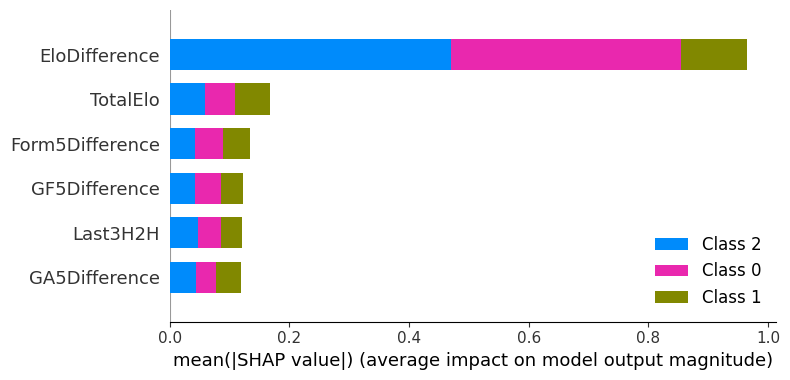

In [135]:
#Global Explainability
shap.summary_plot(shap_values, X_test)

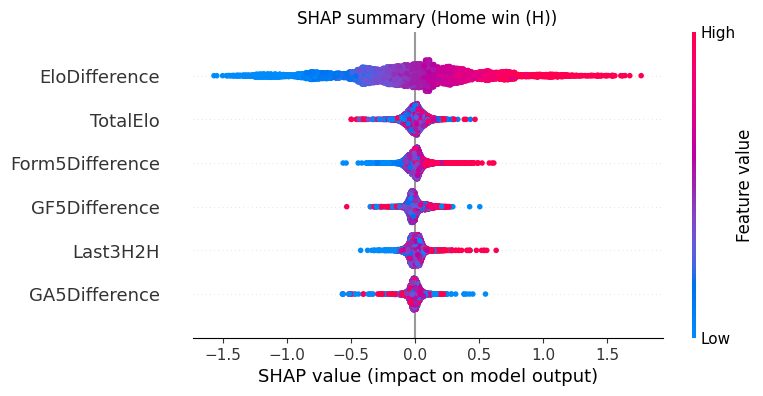

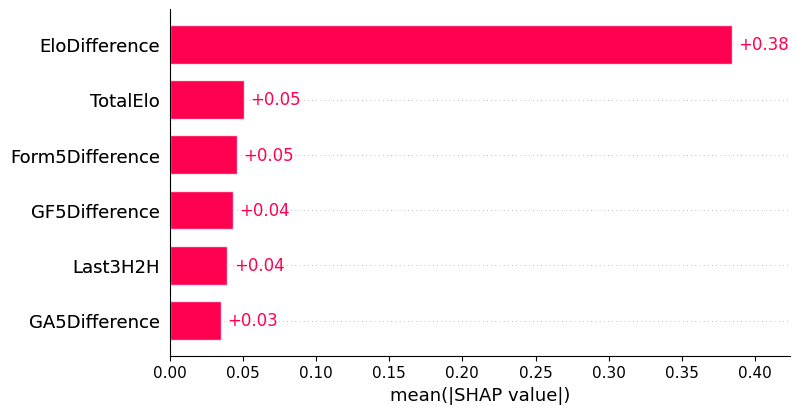

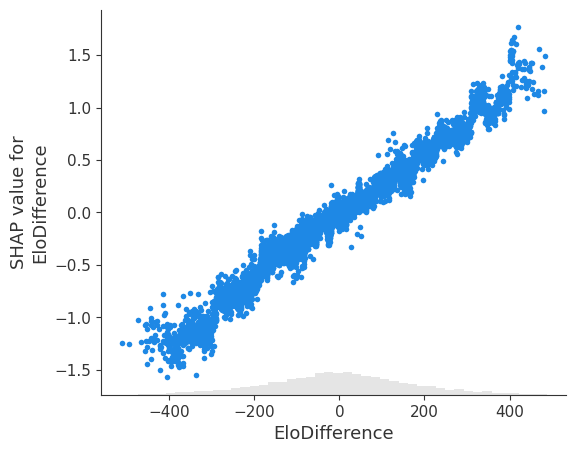

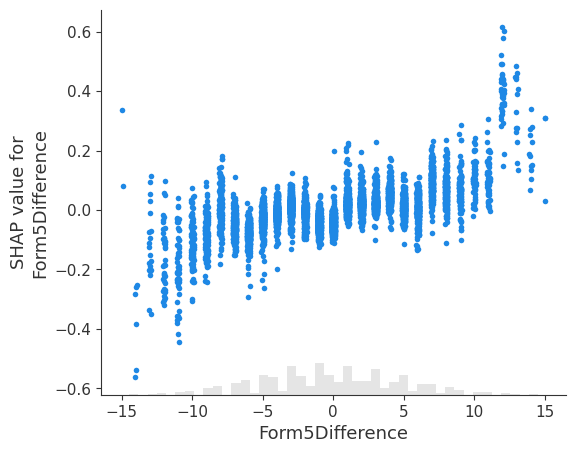

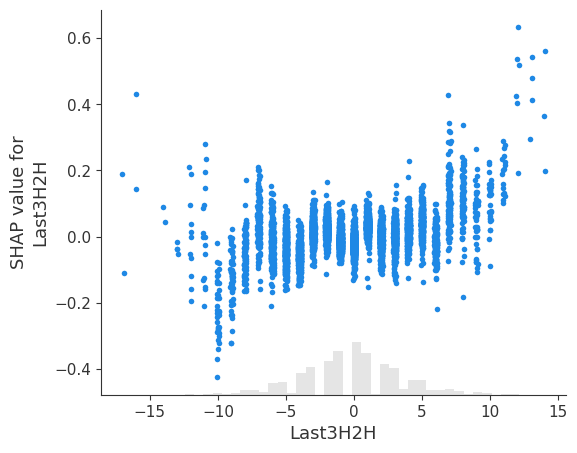

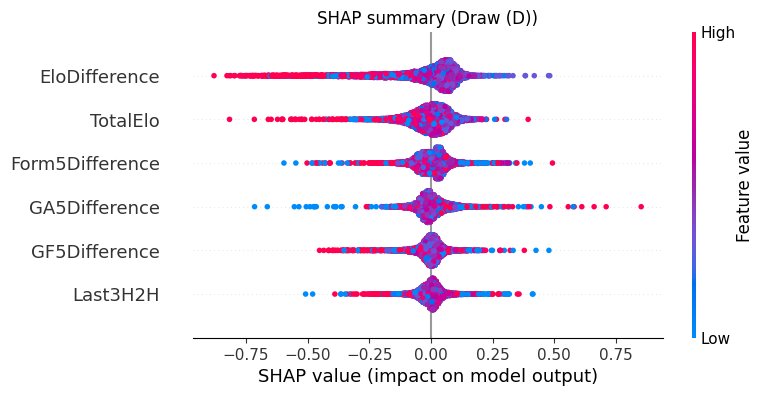

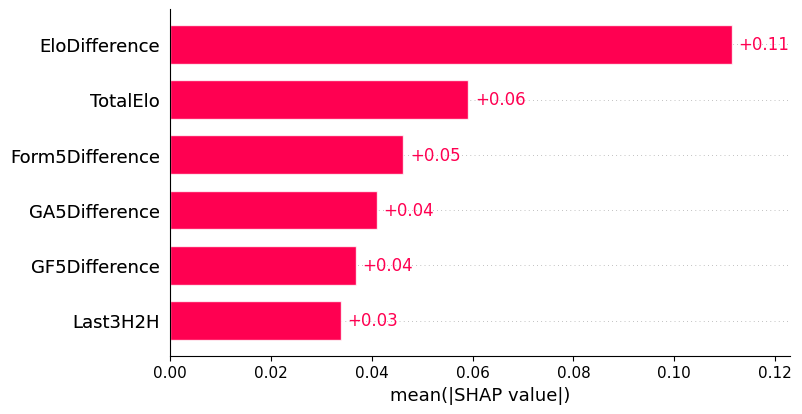

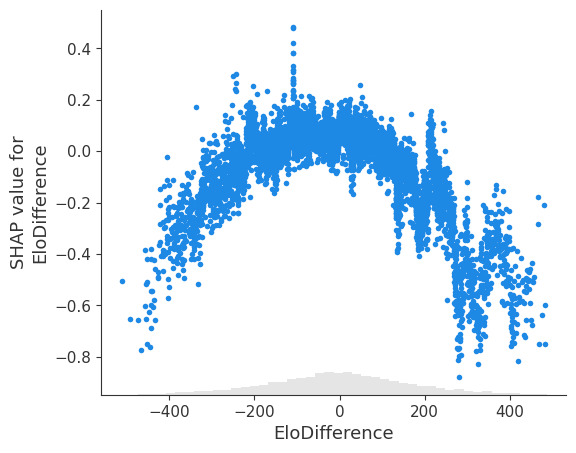

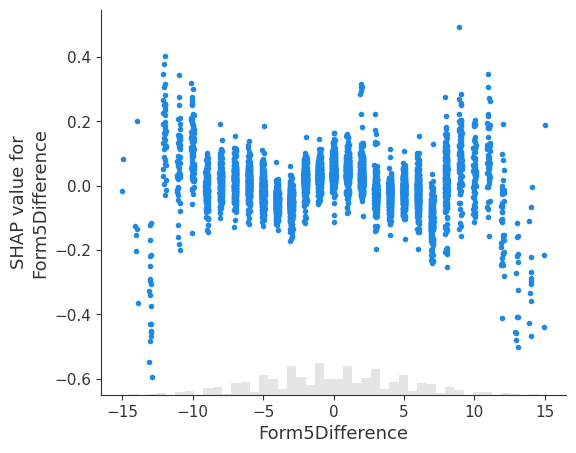

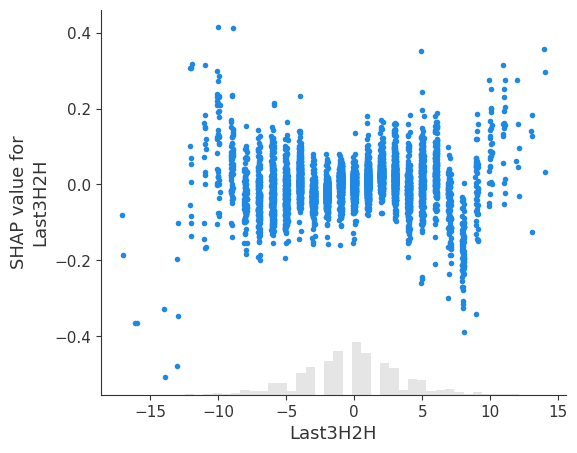

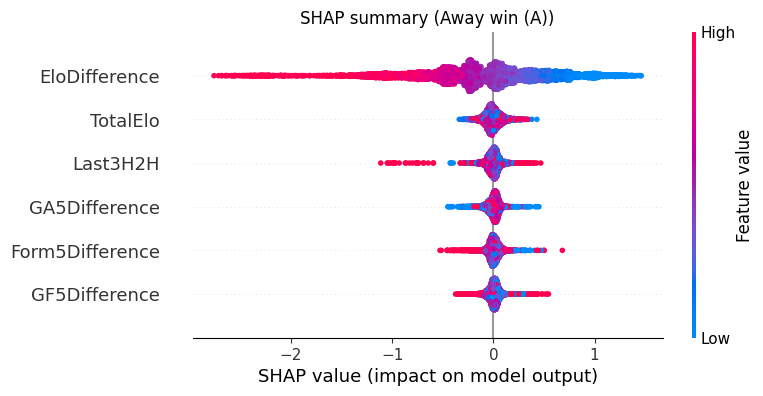

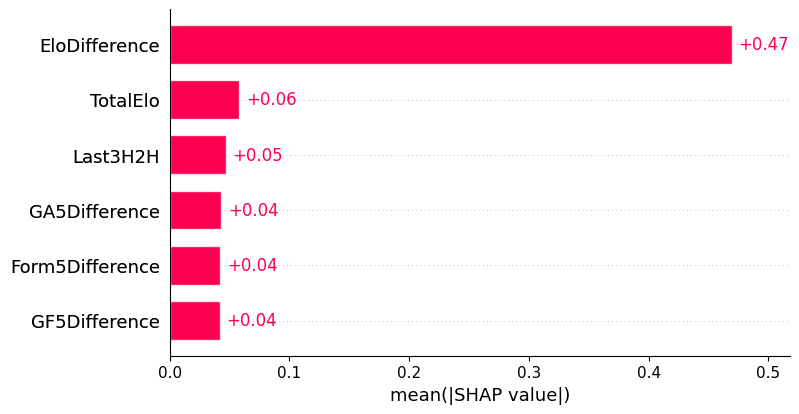

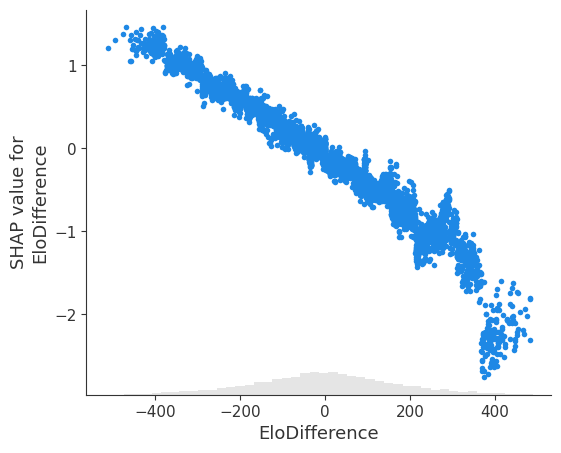

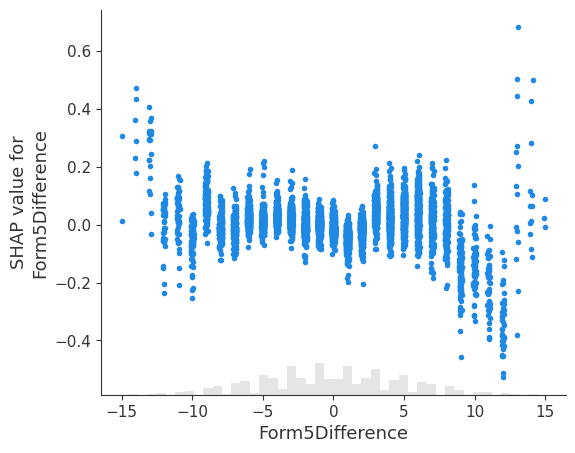

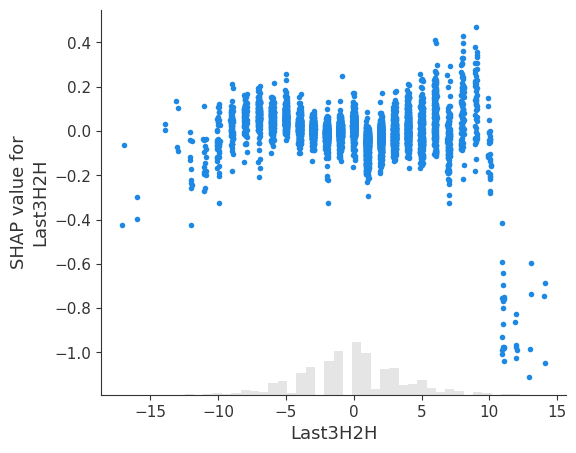

In [143]:
# SHAP explainability (class-specific)
class_names = ['Home win (H)', 'Draw (D)', 'Away win (A)']
class_idx = [0,1,2]  # 0=H, 1=D, 2=A

for class_idx in class_idx:
    # Global: summary & bar for the selected class
    shap.summary_plot(shap_values[..., class_idx], X_test, show=False)
    plt.title(f"SHAP summary ({class_names[class_idx]})")
    plt.show()

    shap.plots.bar(shap_values[..., class_idx], max_display=10)

    # Global: dependence on a few key features
    shap.plots.scatter(shap_values[..., class_idx][:, "EloDifference"])
    shap.plots.scatter(shap_values[..., class_idx][:, "Form5Difference"])
    shap.plots.scatter(shap_values[..., class_idx][:, "Last3H2H"])

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.force(shap_values[0])

In [142]:
shap.decision_plot(shap_values[0].base_values,shap_values[0].values, X_test.iloc[0])

ValueError: The feature_names arg must include all features represented in shap_values.